In [1]:
import copy
import time

import networkx as nx
import pydot
import torch
from IPython.display import clear_output
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from networkx.drawing.nx_pydot import graphviz_layout
from torch.distributions import normal

In [2]:
def create_random_graph(
    n: int, min_b: int, max_b: int, mean: float, dev: float, progress=False
):
    distr = normal.Normal(torch.tensor([mean]), torch.tensor([dev]))

    # create graph with only the root node
    current_num_nodes = 1
    current_node = 0
    G = nx.Graph()
    G.add_node(0)

    # save progress for animation
    if progress:
        G_progress = []
        G_progress.append(copy.deepcopy(G))

    num_children = round(distr.sample().item())
    while num_children < min_b or num_children > max_b:
        num_children = round(distr.sample().item())

    # add nodes according to distribution
    while current_num_nodes + num_children <= n:
        for i in range(num_children):
            G.add_node(current_num_nodes)
            G.add_edge(current_node, current_num_nodes)
            current_num_nodes += 1

            if progress:
                G_progress.append(copy.deepcopy(G))

        current_node += 1
        num_children = round(distr.sample().item())
        while num_children < 1 or num_children > max_b:
            num_children = round(distr.sample().item())

    if current_num_nodes == n:
        if progress:
            return G, G_progress

        return G

    for i in range(n - current_num_nodes):
        G.add_node(current_num_nodes)
        G.add_edge(current_node, current_num_nodes)
        current_num_nodes += 1

        if progress:
            G_progress.append(copy.deepcopy(G))

    if progress:
        return G, G_progress

    return G

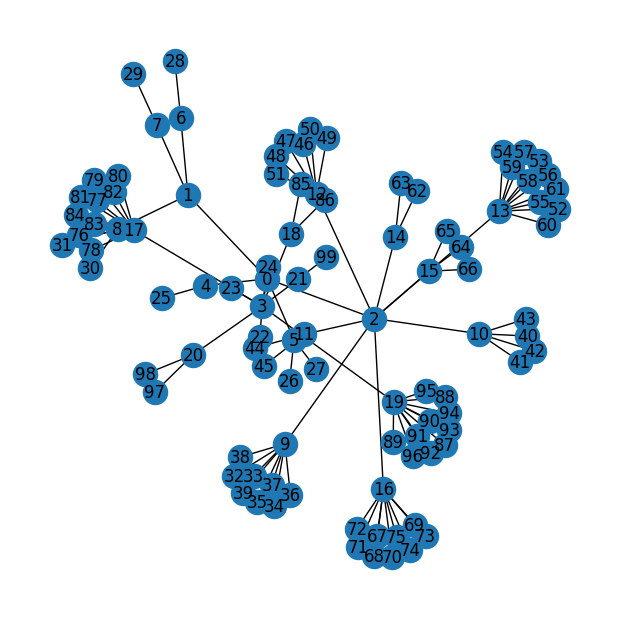

[43, 10, 2, 12, 49]


In [5]:
G1, G1_progress = create_random_graph(100, 1, 10, 5.0, 8.0, progress=True)
plt.figure(figsize=(6, 6))
nx.draw(G1, with_labels=True)
plt.show()
print(nx.shortest_path(G1, 43, 49))

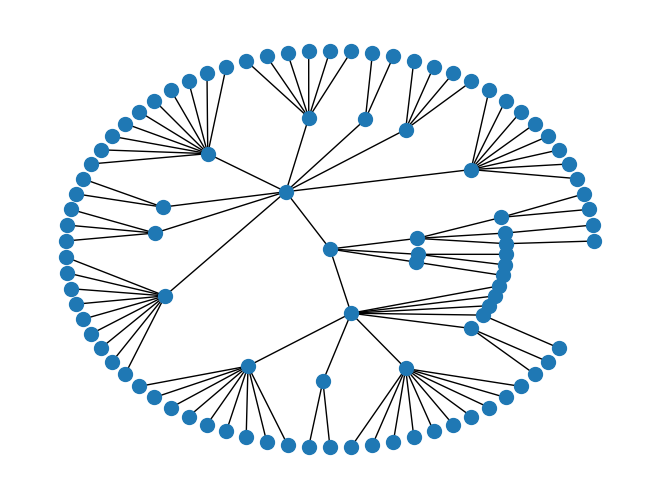

In [6]:
plt.figure(figsize=(8, 8))
pos = nx.nx_agraph.graphviz_layout(G1, prog="twopi")
for i in range(100):
    nx.draw(G1_progress[i], pos, node_size=100)
    plt.show()
    time.sleep(0.5)
    clear_output(wait=True)